In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Most demanded skill for the top 3 most popular data roles in the US

1 - Finding the top 3 most popular data roles

In [73]:
df_us = df.loc[
    df["job_country"] == "United States",
    :
]

top_3_roles = list(df["job_title_short"].value_counts().head(3).index)
top_3_roles

['Data Analyst', 'Data Engineer', 'Data Scientist']

2 - Filter dataframe to have only job postings within the top 3 roles

In [74]:
df_filtered = df_us.loc[
    (df["job_title_short"].isin(top_3_roles)) & df["job_skills"].notna(),
    ["job_title_short", "job_skills"]
].copy()

df_filtered

,job_title_short,job_skills
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
5,Data Engineer,"[python, sql, gcp]"
9,Data Scientist,"[sql, python, r, mongodb, mongodb, sql server,..."
11,Data Engineer,"[python, qlik]"
17,Data Scientist,"[go, apl, excel]"
...,...,...
785648,Data Scientist,"[python, azure, snowflake, spark]"
785651,Data Scientist,[go]
785685,Data Analyst,"[sql, excel]"
785692,Data Scientist,"[python, matlab, r]"


3 - Explode filtered dataframe

In [75]:
exploded_df = df_filtered.explode("job_skills")
exploded_df

,job_title_short,job_skills
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
3,Data Engineer,aws
...,...,...
785692,Data Scientist,matlab
785692,Data Scientist,r
785705,Data Analyst,sql
785705,Data Analyst,python


4 - Aggregate based on job titles

In [76]:
skill_counts = exploded_df.groupby(["job_title_short", "job_skills"]).agg(
    skill_count=("job_skills", "size")
).reset_index()
skill_counts

,job_title_short,job_skills,skill_count
0,Data Analyst,airflow,387
1,Data Analyst,airtable,36
2,Data Analyst,alteryx,2045
3,Data Analyst,angular,129
4,Data Analyst,ansible,48
...,...,...,...
662,Data Scientist,workfront,2
663,Data Scientist,wrike,1
664,Data Scientist,xamarin,3
665,Data Scientist,yarn,119


5 - Calculate percentage of skills per job posting

In [82]:
# return counts of job postings
top_3_roles_count = df_us["job_title_short"].value_counts().head(3).reset_index(name="jobs_count")

In [84]:
# dataframe merging
df_percentage = pd.merge(
    left=skill_counts, 
    right=top_3_roles_count, 
    how="left",
    on="job_title_short"
)
df_percentage


,job_title_short,job_skills,skill_count,jobs_count
0,Data Analyst,airflow,387,67816
1,Data Analyst,airtable,36,67816
2,Data Analyst,alteryx,2045,67816
3,Data Analyst,angular,129,67816
4,Data Analyst,ansible,48,67816
...,...,...,...,...
662,Data Scientist,workfront,2,58830
663,Data Scientist,wrike,1,58830
664,Data Scientist,xamarin,3,58830
665,Data Scientist,yarn,119,58830


In [88]:
df_percentage["skill_percentage"] = 100 * (df_percentage["skill_count"] / df_percentage["jobs_count"])
df_percentage

,job_title_short,job_skills,skill_count,jobs_count,skill_percentage
0,Data Analyst,airflow,387,67816,0.570662
1,Data Analyst,airtable,36,67816,0.053085
2,Data Analyst,alteryx,2045,67816,3.015513
3,Data Analyst,angular,129,67816,0.190221
4,Data Analyst,ansible,48,67816,0.070780
...,...,...,...,...,...
662,Data Scientist,workfront,2,58830,0.003400
663,Data Scientist,wrike,1,58830,0.001700
664,Data Scientist,xamarin,3,58830,0.005099
665,Data Scientist,yarn,119,58830,0.202278


6 - Filter for each job title and create plots

## V1

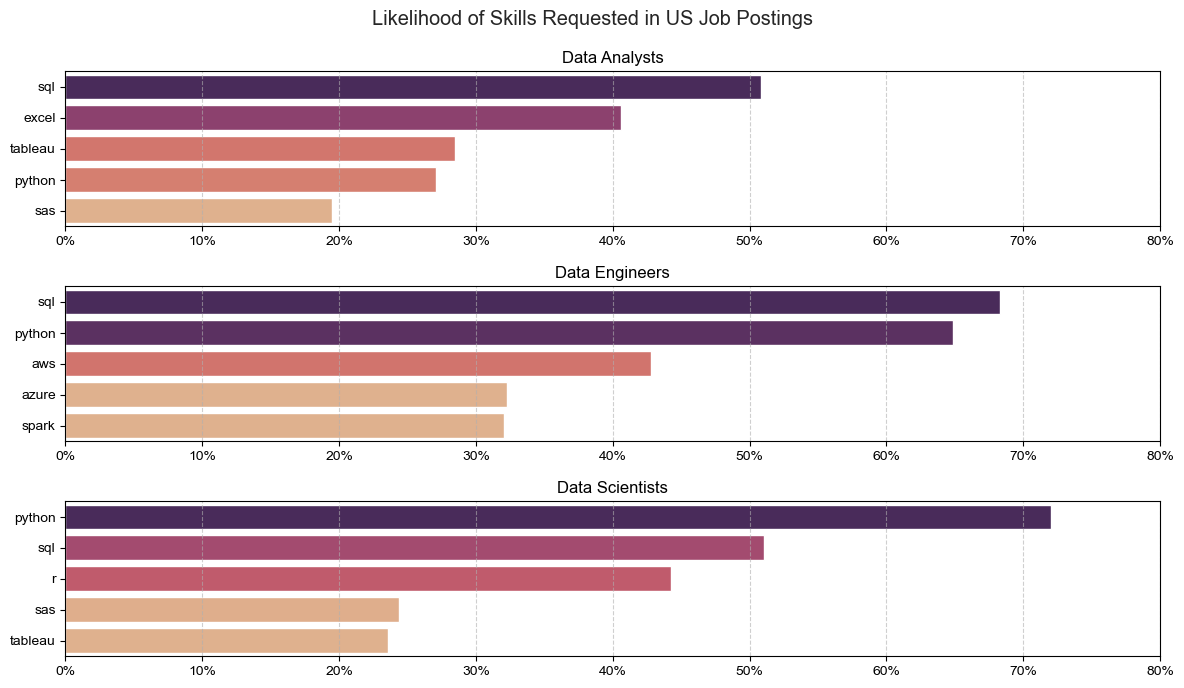

In [98]:
# initial plotting
fig, ax = plt.subplots(nrows=len(top_3_roles), figsize=(12, 7))
sns.set_theme(style="ticks")

for i, job_title in enumerate(top_3_roles):
    # filter data
    plot_df = df_percentage.loc[
        df_percentage["job_title_short"] == job_title,
        :
    ].sort_values(by="skill_count", ascending=False).head()

    # plot
    sns.barplot(
        data=plot_df,
        x="skill_percentage",
        y="job_skills",
        ax=ax[i],
        hue="skill_count",
        palette="flare",
        legend=False
    )

    ax[i].set_title(f"{job_title}s")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, 80)
    ax[i].grid(True, linestyle="--", alpha=0.6)
    ax[i].grid(False, axis="y")
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}%"))

fig.suptitle("Likelihood of Skills Requested in US Job Postings")
plt.tight_layout()
plt.show()

## V2

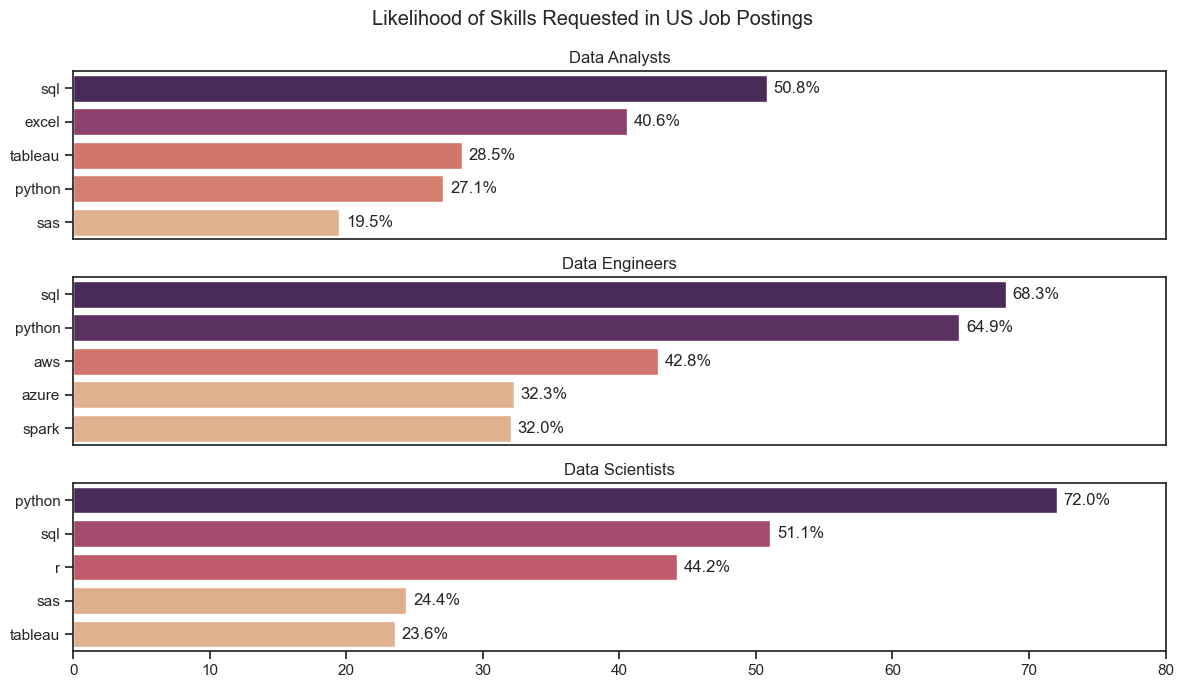

In [112]:
# initial plotting
fig, ax = plt.subplots(nrows=len(top_3_roles), figsize=(12, 7))
sns.set_theme(style="ticks")

for i, job_title in enumerate(top_3_roles):
    # filter data
    plot_df = df_percentage.loc[
        df_percentage["job_title_short"] == job_title,
        :
    ].sort_values(by="skill_count", ascending=False).head()

    # plot
    sns.barplot(
        data=plot_df,
        x="skill_percentage",
        y="job_skills",
        ax=ax[i],
        hue="skill_count",
        palette="flare",
        legend=False
    )

    for n, value in enumerate(plot_df["skill_percentage"]):
        ax[i].text(
            x=value + 0.5, 
            y=n, 
            s=f"{value:.1f}%",
            va="center"
        )

    ax[i].set_title(f"{job_title}s")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, 80)
    ax[i].grid(False, axis="y")

    if i != len(top_3_roles) - 1:
        ax[i].set_xticks([])

fig.suptitle("Likelihood of Skills Requested in US Job Postings")
plt.tight_layout()
plt.show()